# **Laboratorio: matrix Hessiana**

Recordemos que la Hessiana es la matriz cuadrada $n \times n$ que contiene todas las posibles segundas derivadas parciales de una función $f:\mathbb{R}^n → \mathbb{R}$ que recibe como entrada un vector $x ∈ \mathbb{R}^n$.

Durante esta práctica de laboratorio veremos una manera de calcular la matriz Hessiana de una función $f:\mathbb{R}^2 → \mathbb{R}$ y su posterior clasificación a partir de los valores propios.

In [1]:
# Se importan las librerías necesarias para la práctica

import numpy as np
import matplotlib.pyplot as plt

##**1. Función de prueba**

La función con la que trabajaremos a lo largo de esta práctica es:

##$f(x)=x_1^3-3x_1x_2^2$

Empezaremos graficando la función tanto en 3D como en gráfica de contorno, e identificaremos los puntos de valle y montaña que presenta esta función.

###**Grafica 3D**

[Text(0.5, 0.92, 'Gráfica 3D')]

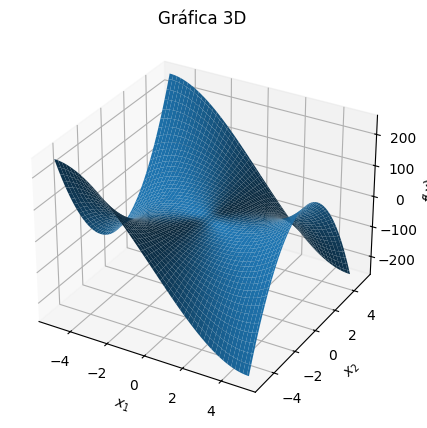

In [ ]:
# Crear malla de puntos en el plano 2D
x_1 = np.linspace(-5,5,100)
x_2 = np.linspace(-5,5,100)
(X_1, X_2) = np.meshgrid(x_1, x_2)

# Se define la función que se desea graficar
f = X_1**3 - 3*X_1*(X_2**2)


fig, ax = plt.subplots(subplot_kw={"projection": "3d"} ,  figsize = (5,5))
surf = ax.plot_surface(X_1, X_2, f)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x)$")
ax.set_box_aspect(aspect=None)
ax.set(title = 'Gráfica 3D')



###**Gráfica de contorno**

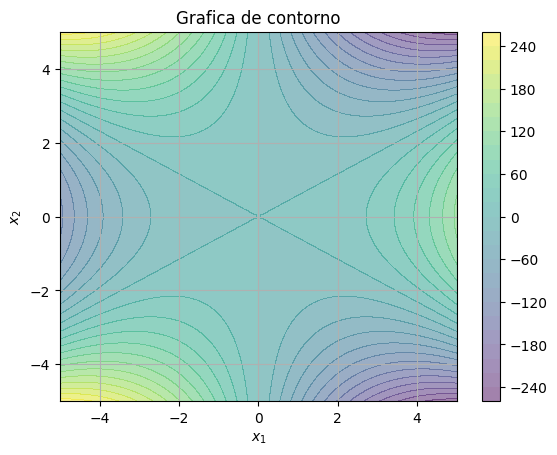

In [ ]:
# Graficar utlizando la función contourf
fig, ax = plt.subplots()
CS1 = ax.contourf(X_1, X_2, f, alpha = 0.5, levels=30)
fig.colorbar(CS1)
ax.grid()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set(title = 'Grafica de contorno')
plt.show()


A través de una inspección visual de la gráfica en 3D y el contorno de la función, podemos ver que el punto donde se encuentra un valle es $[0,0]^T$. Un punto donde hay una montaña puede ser, por ejemplo, el punto $[2,4]^T$

##**2. Calculo de la Hessiana**

Para empezar, vamos a hallar las derivadas parciales de $f$ con respecto a $x1$ y $x2$:

$ \dfrac{∂f}{∂x_1}(x)= 3x_1^2-3x_2^2 $

$ \dfrac{∂f}{∂x_2}(x)= -3x_2x_1 $


Siendo el gradiente:


\begin{align}
∇f(x)=
 \begin{pmatrix}
  3x_1^2-3x_2^2\\
  -6x_1x_2\\
\end{pmatrix}
 \end{align}


Después, vamos a hallar las segundas derivadas parciales, que corresponden a los elementos de la matriz Hessiana:

$ \dfrac{∂^2f}{∂x_1^2}(x)= 6x_1 $

$ \dfrac{∂^2f}{∂x_1x_2}(x)=-6x_2 $

$ \dfrac{∂^2f}{∂x_2^2}(x)= -6x_1  $

Lo que da como resultado la siguiente matriz Hessiana:

\begin{align}
F(x)=
 \begin{pmatrix}
  6x_1 & -6x_2\\
 -6x_2 & -6x_1 \\
\end{pmatrix}
 \end{align}


Ahora bien, para poder evaluar esta matriz en diferentes puntos en 2D, es necesario declarar la siguiente función:

In [ ]:
def hessiana_evaluada(x1,x2):
    f_x1x1 = 6*x1
    f_x1x2 = -6*x2
    f_x2x1 = -6*x2
    f_x2x2 = -6*x1

    return np.array([[f_x1x1, f_x1x2],[f_x2x1,f_x2x2]])

##**3. Categorización de la Hessiana**

## **3.1 Prueba de positividad de una matriz**

A continuación se muestra una función de Python que determina el tipo de matriz que se tiene a partir de sus valores propios, siendo ***M*** una matriz simétrica con tamaño $n\times n$ y elementos reales.


In [ ]:
def test_positividad(M):
  vals ,vec =np.linalg.eig(M)
  if all(val > 0 for val in vals):
    resp="Positiva definida"
  elif all(val >= 0 for val in vals):
    resp="Positiva semidefinida"
  elif all(val < 0 for val in vals):
    resp="Negativa definida"
  elif all(val <= 0 for val in vals):
    resp="Negativa semidefinida"
  else:
    resp="Indefinida"
  return (resp)

**Ejemplo**

Vamos a definir el tipo de matriz que se tiene utilizando la función *test_positividad()* para una matriz ***M*** simétrica de tamaño $n\times n$ y elementos reales.


\begin{align}
M=
 \begin{pmatrix}
 5 & 0 & 0 \\
 0 & 7 & 0\\
 0 & 0 & 9 \\
\end{pmatrix}
 \end{align}


In [ ]:
#Se declara la matriz M utilizando la función Matrix de Sympy
M= np.array([[5,0,0],[0,7,0],[0,0,9]])

# Se utiliza la función test_positividad()
test_positividad(M)

'Positiva definida'

Al ser una matriz diagonal sus valores propios corresponden a los valores de la diagonal. Y estos al ser todos positivos da como resultado una matriz Positiva definida.

## **3.2 Evaluación de la Hessiana en puntos 2D**

Usando le función de Python para categorizar una matriz de acuerdo con su positividad, vamos a categorizar la matriz Hessiana de la función matemática dada par alos siguientes puntos:

* $x=[0,0]^T$
* $x=[2,4]^T$



Primero calculamos la Hessiana para cada punto:


In [ ]:
# Para el punto valle (0,0)

hessiana1= hessiana_evaluada(0,0)
print("Hessiana en el punto valle (0,0):", hessiana1)

# Para el punto montaña (2,4)
hessiana2= hessiana_evaluada(2,4)
print("Hessiana en el punto montaña (2,4):", hessiana2)


Hessiana en el punto valle (0,0): [[0 0]
 [0 0]]
Hessiana en el punto montaña (2,4): [[ 12 -24]
 [-24 -12]]


Corroboramos los valores propios de la matriz:

In [ ]:
# Valores propios para la Hessiana evaluada en el punto valle (0,0)
eigenvals1= np.linalg.eigvals(hessiana1)
print("Valores propios Hessiana 1:",eigenvals1)

# Valores propios para la Hessiana evaluada en el punto montaña (2,4)
eigenvals2= np.linalg.eigvals(hessiana2)
print("Valores propios Hessiana 2:",eigenvals2)

Valores propios Hessiana 1: [0. 0.]
Valores propios Hessiana 2: [ 26.83281573 -26.83281573]


y por último hacemos el test de positividad usando la función de Pyhton:

In [ ]:
# Hessiana en el punto (0,0)
t1= test_positividad(hessiana1)


#Hessiana en el punto (2,4)
t2= test_positividad(hessiana2)

print("La Hessiana en el punto [0,0] es",t1,"y la Hessiana en el punto [2,4]]",t2)

La Hessiana en el punto [0,0] es Positiva semidefinida y la Hessiana en el punto [2,4]] Indefinida


##**4. Ejercicios**

####**Ejercicio 1: Pruebe la función *test_positividad()* en la matriz presentada a continuación. Esta matriz se genera de forma aleatoria con una semilla fija.**




In [ ]:
#Semilla fija
semilla =np.random.seed(21)

#Matriz triangular inferior
triangular_inf = np.random.randint(-10, 10, size=(15, 15))

#Matriz simétrica
matriz = np.tril(triangular_inf) + np.tril(triangular_inf, -1).T

print(matriz)

[[ -1  -6  -7  -7   1   6   7  -1   4  -7   0  -6   8  -1   4]
 [ -6  -4   6  -6 -10  -7  -9  -9  -9  -8   4   1   6   1  -5]
 [ -7   6  -9   2   4  -9   1   6  -6   8   0  -9   4   5  -8]
 [ -7  -6   2   2   5   9   1   1 -10   6   7   6  -3   3  -9]
 [  1 -10   4   5  -3  -9   3   3  -7   5  -6   3   5  -7   1]
 [  6  -7  -9   9  -9  -9  -5  -7  -3   8  -7   3  -9   9   1]
 [  7  -9   1   1   3  -5  -6   0 -10   8  -5   5   3   2   5]
 [ -1  -9   6   1   3  -7   0  -1  -7   4   1   0  -1   1  -4]
 [  4  -9  -6 -10  -7  -3 -10  -7   2  -4   9  -8   0  -3  -9]
 [ -7  -8   8   6   5   8   8   4  -4  -7  -7   5  -3  -1  -8]
 [  0   4   0   7  -6  -7  -5   1   9  -7  -8   1 -10 -10   1]
 [ -6   1  -9   6   3   3   5   0  -8   5   1   7   7   8  -5]
 [  8   6   4  -3   5  -9   3  -1   0  -3 -10   7  -9  -7  -9]
 [ -1   1   5   3  -7   9   2   1  -3  -1 -10   8  -7  -7   3]
 [  4  -5  -8  -9   1   1   5  -4  -9  -8   1  -5  -9   3  -3]]


In [ ]:
matriz_test= test_positividad(matriz)
print("La matriz es",matriz_test)

La matriz es Indefinida


####**Ejercicio 2: Tenga en cuenta la siguiente función:**
$f_1(x)=(x_1-2)^4 -x_2^2$



Grafique la función $f(x)$ en 3D y contorno para el rango $-3 ≤ x_1 ≤ 5$ y $-4 ≤ x_2≤4$

[Text(0.5, 0.92, 'Gráfica 3D')]

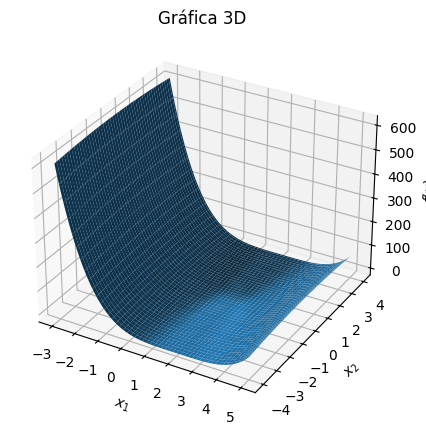

In [ ]:
x1 = np.linspace(-3,5,100)
x2 = np.linspace(-4,4,100)
(X1, X2) = np.meshgrid(x1, x2)

f = (X1-2)**4 - X2**2

fig, ax = plt.subplots(subplot_kw={"projection": "3d"} ,  figsize = (5,5))
surf = ax.plot_surface(X1, X2, f)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x)$")
ax.set_box_aspect(aspect=None)
ax.set(title = 'Gráfica 3D')




Calcule la matriz Hessiana de $f_1(x)$ y redefina la función de Python *hessiana_evaluada(x1,x2)*:

In [ ]:
def hessiana1(x1,x2):
    f_x1x1 = 12*(x1-2)**2
    f_x1x2 = 0
    f_x2x1 = 0
    f_x2x2 = -2
    return np.array([[f_x1x1, f_x1x2],[f_x2x1,f_x2x2]])


Evalúe la matriz Hessiana en los puntos $x=[2,0]^T$ y $x=[4,3]^T$,  y categorice las matrices resultantes mediante el test de positividad.



In [ ]:
hessiana_1 = hessiana1(2,0)
print("Hessiana en el punto valle (2,0):", hessiana_1)
test_h1= test_positividad(hessiana_1)
print("test de positividad: ", test_h1)
print("La Hessiana en el punto [2,0] es",test_h1)
hessiana_2 = hessiana1(4,3)
print("Hessiana en el punto montaña (4,3):", hessiana_2)
test_h2= test_positividad(hessiana_2)
print("test de positividad: ", test_h2)

Hessiana en el punto valle (2,0): [[ 0  0]
 [ 0 -2]]
test de positividad:  Negativa semidefinida
La Hessiana en el punto [2,0] es Negativa semidefinida
Hessiana en el punto montaña (4,3): [[48  0]
 [ 0 -2]]
test de positividad:  Indefinida


calculo de valores propios y vectores propios


In [7]:
m = np.array([[6,2],[2,6]])
eigvals, eigvectores = np.linalg.eig(m)
print(eigvals)
print(eigvectores)


[8. 4.]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
